# 1. Подготовка набора данных детекции

Набор данных Russian license plates classification by this type Model
https://universe.roboflow.com/testcarplate/russian-license-plates-classification-by-this-type

скачаны оригинальные 2030 изображений без предобработки через форк https://app.roboflow.com/s-workspace-9chy5/license-plate-4-corner-detection-v2-isxsj-rt4nr/1?queryText=&pageSize=50&startingIndex=0&browseQuery=true

Приведение в соответствие формату

In [ ]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any


ROOT_DIR = Path(r"C:\Russian license plates classification by this type Model")

CONVERSION_PATHS = [
    {
        "input": ROOT_DIR / "train" / "_annotations.coco.json",
        "output": ROOT_DIR / "train.json",
    },
    {
        "input": ROOT_DIR / "valid" / "_annotations.coco.json",
        "output": ROOT_DIR / "valid.json",
    },
    {
        "input": ROOT_DIR / "test" / "_annotations.coco.json",
        "output": ROOT_DIR / "test.json",
    },
]


def _to_float(value: Any, default: float = 0.0) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def _bbox_to_polygon(bbox: list[Any] | tuple[Any, ...]) -> list[float]:
    if len(bbox) != 4:
        return []
    x = _to_float(bbox[0])
    y = _to_float(bbox[1])
    w = _to_float(bbox[2])
    h = _to_float(bbox[3])
    return [x, y, x + w, y, x + w, y + h, x, y + h]


def _keypoints_to_polygon(keypoints: list[Any] | tuple[Any, ...]) -> list[float]:
    if len(keypoints) < 12:
        return []

    points: list[float] = []
    for i in range(0, 12, 3):
        x = _to_float(keypoints[i])
        y = _to_float(keypoints[i + 1])
        visibility = _to_float(keypoints[i + 2], 2.0)
        if visibility > 0:
            points.extend([x, y])

    if len(points) >= 8:
        return points[:8]
    return []


def _build_segmentation(annotation: dict[str, Any]) -> list[float]:
    keypoints = annotation.get("keypoints", [])
    if isinstance(keypoints, (list, tuple)):
        polygon = _keypoints_to_polygon(keypoints)
        if polygon:
            return polygon

    bbox = annotation.get("bbox", [])
    if isinstance(bbox, (list, tuple)):
        return _bbox_to_polygon(bbox)

    return []


def convert_file(input_json: Path, output_json: Path) -> None:
    with input_json.open("r", encoding="utf-8") as source_file:
        source_data = json.load(source_file)

    source_images = source_data.get("images", [])
    source_annotations = source_data.get("annotations", [])
    source_categories = source_data.get("categories", [])

    category_lookup = {
        int(category.get("id")): category
        for category in source_categories
        if "id" in category
    }

    used_category_ids = sorted(
        {
            int(annotation.get("category_id"))
            for annotation in source_annotations
            if "category_id" in annotation
        }
    )

    category_id_map = {
        old_category_id: new_category_id
        for new_category_id, old_category_id in enumerate(used_category_ids, start=1)
    }

    target_categories: list[dict[str, Any]] = []
    for old_category_id in used_category_ids:
        source_category = category_lookup.get(
            old_category_id,
            {
                "name": f"class_{old_category_id}",
                "supercategory": "none",
            },
        )
        target_categories.append(
            {
                "id": category_id_map[old_category_id],
                "name": str(source_category.get("name", f"class_{old_category_id}")),
                "supercategory": str(source_category.get("supercategory", "none")),
            }
        )

    target_images: list[dict[str, Any]] = []
    for image in source_images:
        target_images.append(
            {
                "id": int(image.get("id", 0)),
                "file_name": str(image.get("file_name", "")),
                "width": int(image.get("width", 0)),
                "height": int(image.get("height", 0)),
            }
        )

    target_annotations: list[dict[str, Any]] = []
    new_annotation_id = 1
    for source_annotation in source_annotations:
        source_category_id = int(source_annotation.get("category_id", -1))
        if source_category_id not in category_id_map:
            continue

        bbox = source_annotation.get("bbox", [0.0, 0.0, 0.0, 0.0])
        target_bbox = [_to_float(value) for value in bbox[:4]]
        if len(target_bbox) < 4:
            target_bbox += [0.0] * (4 - len(target_bbox))

        area = _to_float(source_annotation.get("area", 0.0), 0.0)
        if area <= 0.0:
            area = max(target_bbox[2], 0.0) * max(target_bbox[3], 0.0)

        target_annotations.append(
            {
                "id": new_annotation_id,
                "image_id": int(source_annotation.get("image_id", 0)),
                "category_id": category_id_map[source_category_id],
                "segmentation": [_build_segmentation(source_annotation)],
                "area": area,
                "bbox": target_bbox,
                "iscrowd": int(source_annotation.get("iscrowd", 0)),
            }
        )
        new_annotation_id += 1

    result = {
        "images": target_images,
        "annotations": target_annotations,
        "categories": target_categories,
    }

    with output_json.open("w", encoding="utf-8") as out_file:
        json.dump(result, out_file, ensure_ascii=False, indent=4)


def main() -> None:
    if not ROOT_DIR.exists():
        print(f"[SKIP] Не найдена папка датасета: {ROOT_DIR}")
        return

    for pair in CONVERSION_PATHS:
        input_path = pair["input"]
        output_path = pair["output"]

        if not input_path.exists():
            print(f"[SKIP] Не найден файл: {input_path}")
            continue

        convert_file(input_path, output_path)
        print(f"[OK] {input_path} -> {output_path}")


if __name__ == "__main__":
    main()


[OK] C:\Russian license plates classification by this type Model\train\_annotations.coco.json -> C:\Russian license plates classification by this type Model\train.json
[OK] C:\Russian license plates classification by this type Model\valid\_annotations.coco.json -> C:\Russian license plates classification by this type Model\valid.json
[OK] C:\Russian license plates classification by this type Model\test\_annotations.coco.json -> C:\Russian license plates classification by this type Model\test.json


Статистика

,split,source,images,objects,objects_per_image,unique_resolutions
0,train,C:\Russian license plates classification by th...,1405,1444,1.028,371
1,valid,C:\Russian license plates classification by th...,407,415,1.020,112
2,test,C:\Russian license plates classification by th...,217,218,1.005,74
3,all,C:\Russian license plates classification by th...,2029,2077,1.024,495


,resolution,images,objects
0,1440x1080,563,567
1,416x416,352,356
2,1200x900,168,170
3,1920x1080,90,94
4,3840x2160,85,85
...,...,...,...
490,1444x1172,1,1
491,1300x981,1,1
492,1200x842,1,1
493,600x416,1,1


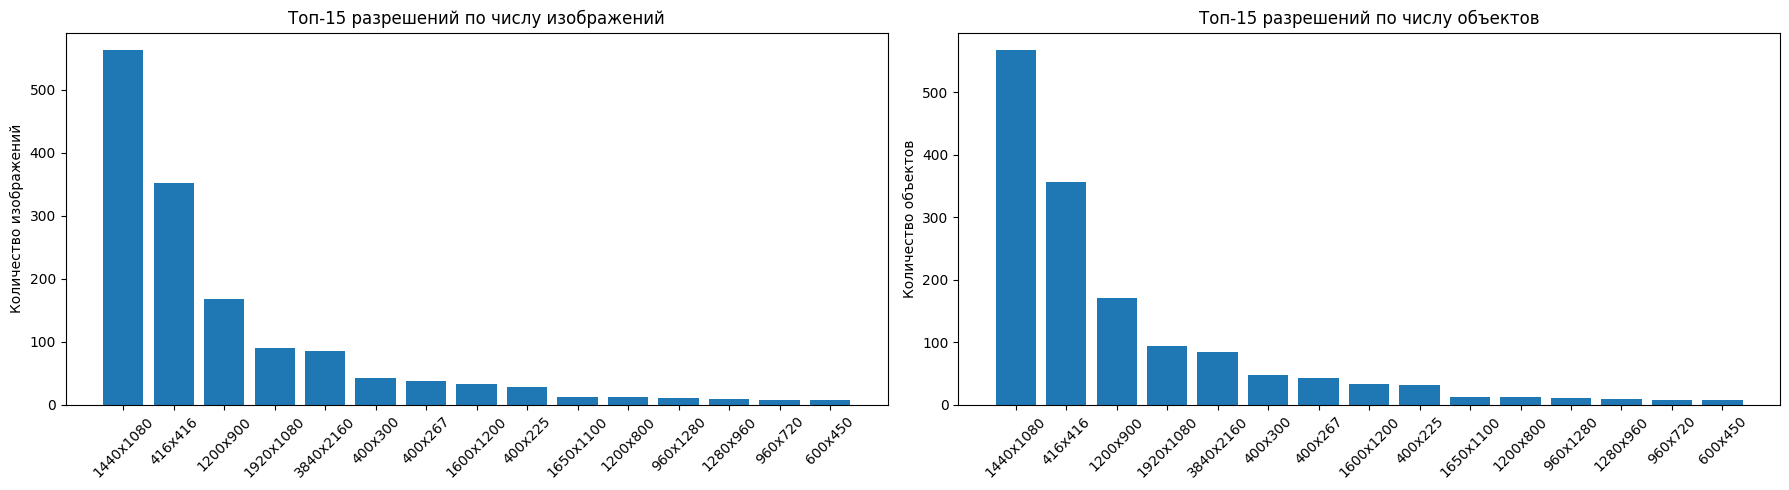

In [8]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None


ROOT_DIR = Path(r"C:\Russian license plates classification by this type Model")
SPLITS = ("train", "valid", "test")


def resolve_json_path(split: str) -> Path:
    candidates = [
        ROOT_DIR / f"{split}.json",
        ROOT_DIR / split / "_annotations.coco.json",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Не найден JSON для split='{split}'")


split_stats: list[dict] = []
overall_resolution_counter: Counter[str] = Counter()
overall_object_counter_by_resolution: Counter[str] = Counter()

for split in SPLITS:
    json_path = resolve_json_path(split)

    with json_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    images = data.get("images", [])
    annotations = data.get("annotations", [])

    objects_per_image = Counter(int(ann.get("image_id", -1)) for ann in annotations)
    resolution_counter: Counter[str] = Counter()
    object_counter_by_resolution: Counter[str] = Counter()

    for image in images:
        image_id = int(image.get("id", -1))
        width = int(image.get("width", 0))
        height = int(image.get("height", 0))
        resolution = f"{width}x{height}"

        resolution_counter[resolution] += 1
        object_counter_by_resolution[resolution] += objects_per_image.get(image_id, 0)

    overall_resolution_counter.update(resolution_counter)
    overall_object_counter_by_resolution.update(object_counter_by_resolution)

    split_stats.append(
        {
            "split": split,
            "source": str(json_path),
            "images": len(images),
            "objects": len(annotations),
            "objects_per_image": round(len(annotations) / len(images), 3) if images else 0.0,
            "unique_resolutions": len(resolution_counter),
        }
    )

total_images = sum(row["images"] for row in split_stats)
total_objects = sum(row["objects"] for row in split_stats)

overall_row = {
    "split": "all",
    "source": str(ROOT_DIR),
    "images": total_images,
    "objects": total_objects,
    "objects_per_image": round(total_objects / total_images, 3) if total_images else 0.0,
    "unique_resolutions": len(overall_resolution_counter),
}

resolution_rows = [
    {
        "resolution": resolution,
        "images": image_count,
        "objects": overall_object_counter_by_resolution[resolution],
    }
    for resolution, image_count in overall_resolution_counter.most_common()
]

if pd is not None:
    display(pd.DataFrame(split_stats + [overall_row]))
    display(pd.DataFrame(resolution_rows))
else:
    print("=== Split stats ===")
    for row in split_stats + [overall_row]:
        print(row)

    print("\n=== Resolution distribution ===")
    for row in resolution_rows:
        print(row)

if plt is not None and resolution_rows:
    top_n = 15
    top_rows = resolution_rows[:top_n]

    labels = [row["resolution"] for row in top_rows]
    image_counts = [row["images"] for row in top_rows]
    object_counts = [row["objects"] for row in top_rows]

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    axes[0].bar(labels, image_counts)
    axes[0].set_title(f"Топ-{top_n} разрешений по числу изображений")
    axes[0].set_ylabel("Количество изображений")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(labels, object_counts)
    axes[1].set_title(f"Топ-{top_n} разрешений по числу объектов")
    axes[1].set_ylabel("Количество объектов")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


# 2. Обучение детектора

In [1]:
from manuscript.detectors import EAST


train_images = [r"C:\Russian license plates classification by this type Model\train",
                r"C:\Russian license plates classification by this type Model\valid"]
train_annotations = [r"C:\Russian license plates classification by this type Model\train.json",
                     r"C:\Russian license plates classification by this type Model\valid.json"]

val_images = r"C:\Russian license plates classification by this type Model\test"
val_annotations = r"C:\Russian license plates classification by this type Model\test.json"


EAST.train(train_images=train_images,
           train_anns=train_annotations,
           val_images=val_images,
           val_anns=val_annotations,
           freeze_first=True,
           model_name="east_russian_license_plates",
           target_size=1024,
           epochs=100,
           batch_size=2,
           resume_from=r"C:\east_50_g1.pth")

c:\Users\USER\manuscript-ocr-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\USER\manuscript-ocr-2\src\manuscript\detectors\_east\dataset.py:516: UserWarning: EASTDataset: found 4 images without valid quads — they will be skipped
  warnings.warn(
C:\Users\USER\manuscript-ocr-2\src\manuscript\detectors\_east\dataset.py:516: UserWarning: EASTDataset: found 3 images without valid quads — they will be skipped
  warnings.warn(
C:\Users\USER\manuscript-ocr-2\src\manuscript\detectors\_east\dataset.py:516: UserWarning: EASTDataset: found 1 images without valid quads — they will be skipped
  warnings.warn(
C:\Users\USER\manuscript-ocr-2\src\manuscript\detectors\_east\train_utils.py:368: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` ins

Training configuration saved to: c:\Users\USER\manuscript-ocr-2\notebooks\experiments\east_russian_license_plates\training_config.json


Train 1:   0%|          | 0/903 [00:00<?, ?it/s]C:\Users\USER\manuscript-ocr-2\src\manuscript\detectors\_east\train_utils.py:371: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast()
Train 10: 100%|██████████| 903/903 [03:56<00:00,  3.81it/s]


: 

[EAST] Device configuration:
  Requested device: cpu
  Requested providers: ['CPUExecutionProvider']
  Active providers: ['CPUExecutionProvider']
  Running on: CPUExecutionProvider


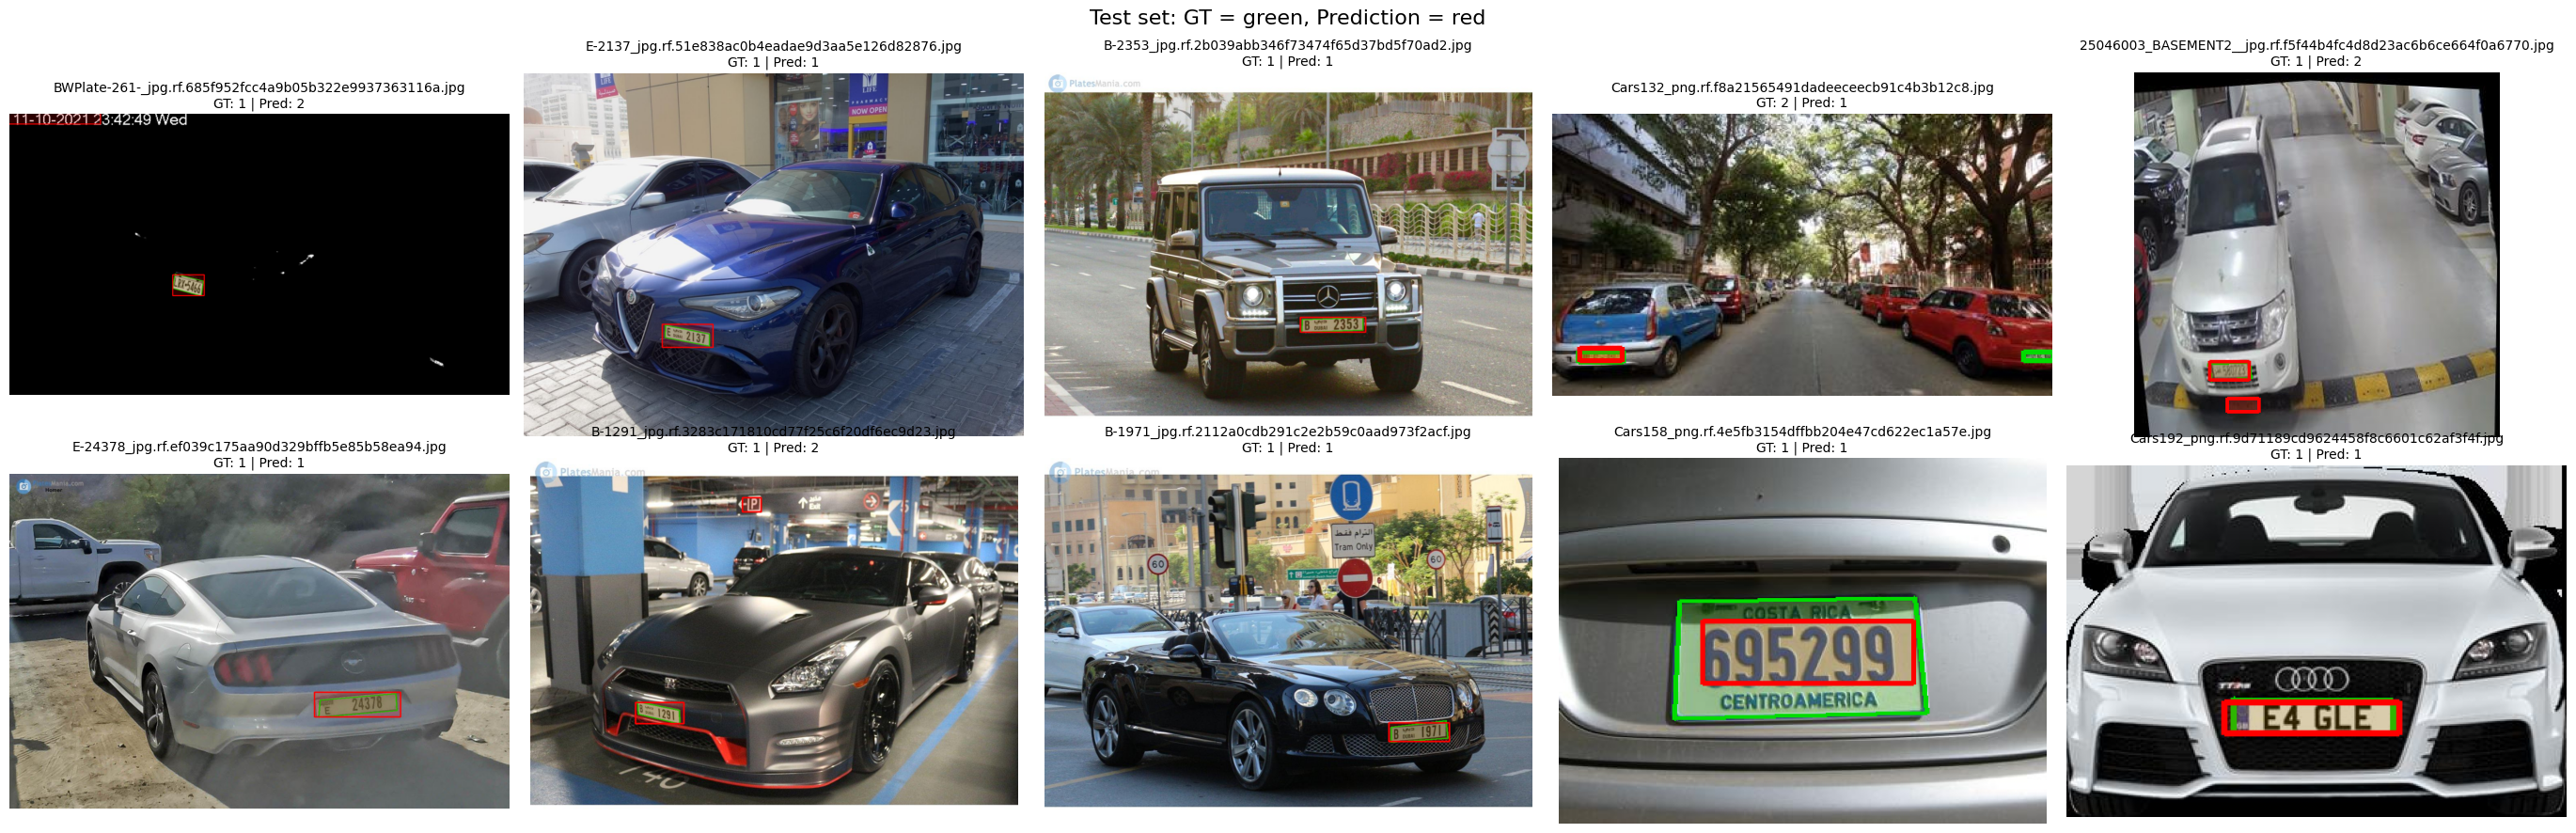

In [13]:
from __future__ import annotations

import json
import math
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from manuscript.detectors import EAST


ROOT_DIR = Path(r"C:\Russian license plates classification by this type Model")
TEST_IMAGES_DIR = ROOT_DIR / "test"
TEST_JSON = ROOT_DIR / "test.json"
N_SAMPLES = 10
RANDOM_SEED = 42
MAX_DISPLAY_SIDE = 900

DETECTOR = EAST(weights = r"C:\Users\USER\manuscript-ocr-2\notebooks\experiments\east_russian_license_plates\checkpoints\best_model.onnx", target_size=1024)

if not TEST_JSON.exists():
    TEST_JSON = ROOT_DIR / "test" / "_annotations.coco.json"

with TEST_JSON.open("r", encoding="utf-8") as f:
    test_data = json.load(f)

images = test_data.get("images", [])
annotations = test_data.get("annotations", [])

anns_by_image_id = defaultdict(list)
for ann in annotations:
    anns_by_image_id[int(ann["image_id"])].append(ann)


def ann_to_polygon(ann: dict) -> list[tuple[float, float]]:
    segmentation = ann.get("segmentation", [])
    if isinstance(segmentation, list) and segmentation:
        first = segmentation[0]
        if isinstance(first, list) and len(first) >= 8:
            pts = first[:8]
            return [(float(pts[i]), float(pts[i + 1])) for i in range(0, 8, 2)]
        if not isinstance(first, list) and len(segmentation) >= 8:
            pts = segmentation[:8]
            return [(float(pts[i]), float(pts[i + 1])) for i in range(0, 8, 2)]

    keypoints = ann.get("keypoints", [])
    if isinstance(keypoints, list) and len(keypoints) >= 12:
        pts = []
        for i in range(0, 12, 3):
            x = float(keypoints[i])
            y = float(keypoints[i + 1])
            visibility = float(keypoints[i + 2])
            if visibility > 0:
                pts.append((x, y))
        if len(pts) >= 4:
            return pts[:4]

    bbox = ann.get("bbox", [])
    if isinstance(bbox, list) and len(bbox) == 4:
        x, y, w, h = map(float, bbox)
        return [(x, y), (x + w, y), (x + w, y + h), (x, y + h)]

    return []


def page_to_polygons(page) -> list[list[tuple[float, float]]]:
    polygons = []
    for block in page.blocks:
        for line in block.lines:
            for word in line.words:
                poly = [(float(x), float(y)) for x, y in word.polygon]
                if len(poly) >= 4:
                    polygons.append(poly)
    return polygons


def draw_polygons(
    image: Image.Image,
    polygons: list[list[tuple[float, float]]],
    outline_color: tuple[int, int, int, int],
    fill_color: tuple[int, int, int, int],
    width: int = 4,
) -> Image.Image:
    base = image.convert("RGBA")
    overlay = Image.new("RGBA", base.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)

    for poly in polygons:
        pts = [(int(round(x)), int(round(y))) for x, y in poly]
        if len(pts) >= 3:
            draw.polygon(pts, outline=outline_color, fill=fill_color)
            draw.line(pts + [pts[0]], fill=outline_color, width=width)

    return Image.alpha_composite(base, overlay).convert("RGB")


def resize_for_display(image: Image.Image, max_side: int = 900) -> Image.Image:
    w, h = image.size
    scale = min(1.0, max_side / max(w, h))
    if scale >= 1.0:
        return image
    new_size = (int(w * scale), int(h * scale))
    return image.resize(new_size)


eligible_images = [
    img for img in images
    if anns_by_image_id[int(img["id"])] and (TEST_IMAGES_DIR / str(img["file_name"])).exists()
]

random.seed(RANDOM_SEED)
sampled_images = random.sample(eligible_images, min(N_SAMPLES, len(eligible_images)))

cols = 5
rows = math.ceil(len(sampled_images) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.5, rows * 4.5))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, image_info in zip(axes, sampled_images):
    image_id = int(image_info["id"])
    image_path = TEST_IMAGES_DIR / str(image_info["file_name"])

    pil_image = Image.open(image_path).convert("RGB")

    gt_polygons = [
        poly for poly in (ann_to_polygon(ann) for ann in anns_by_image_id[image_id])
        if poly
    ]

    pred_result = DETECTOR.predict(str(image_path))
    pred_polygons = page_to_polygons(pred_result["page"])

    vis = pil_image
    vis = draw_polygons(
        vis,
        gt_polygons,
        outline_color=(0, 220, 0, 255),
        fill_color=(0, 220, 0, 45),
        width=4,
    )
    vis = draw_polygons(
        vis,
        pred_polygons,
        outline_color=(255, 0, 0, 255),
        fill_color=(255, 0, 0, 45),
        width=4,
    )
    vis = resize_for_display(vis, max_side=MAX_DISPLAY_SIDE)

    ax.imshow(vis)
    ax.set_title(
        f"{image_path.name}\nGT: {len(gt_polygons)} | Pred: {len(pred_polygons)}",
        fontsize=10,
    )
    ax.axis("off")

for ax in axes[len(sampled_images):]:
    ax.axis("off")

fig.suptitle("Test set: GT = green, Prediction = red", fontsize=16)
plt.tight_layout()
plt.show()